### Imports and Configuration


In [1]:
# Import shared libraries, metrics, and utilities used across the full dataset modeling workflow.
# Keep metric imports centralized so split evaluation and cross-validation use consistent definitions.
# Configure warnings once to keep lengthy experiment logs readable during repeated notebook runs.

import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score,
                              average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_validate

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Paths and Data Loading


In [3]:
# Build project-relative paths to keep the notebook portable across machines and environments.
# Load prepared full dataset train/validation/test splits so each algorithm is tested on identical partitions.
# Ensure output directories exist before fitting so artifact persistence does not fail at completion.

from pathlib import Path

NOTEBOOK_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI/notebooks')
BASE_DIR     = Path('/content/drive/MyDrive/MLmodeling/XAI')
SPLITS_DIR   = BASE_DIR / 'splits' / 'full_dataset'
MODEL_DIR    = BASE_DIR / 'models' / 'full_dataset'
RESULT_DIR   = BASE_DIR / 'results' / 'full_dataset'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Train is 5.4M rows — load in chunks to avoid memory issues
print('Loading X_train in chunks...')
X_train = pd.read_csv(SPLITS_DIR / 'X_train.csv', dtype=np.float32).values
y_train = pd.read_csv(SPLITS_DIR / 'y_train.csv').squeeze().values

# Val and test are smaller — load directly
X_val  = pd.read_csv(SPLITS_DIR / 'X_val.csv',  dtype=np.float32).values
X_test = pd.read_csv(SPLITS_DIR / 'X_test.csv', dtype=np.float32).values
y_val  = pd.read_csv(SPLITS_DIR / 'y_val.csv').squeeze().values
y_test = pd.read_csv(SPLITS_DIR / 'y_test.csv').squeeze().values

print(f'Train Data Load')
print(f'Val  Data Load')
print(f'Test  Data Load')


Loading X_train in chunks...
Train Data Load
Val  Data Load
Test  Data Load


### Model Definition


In [4]:
# Define DecisionTree with explicit hyperparameters so this run stays reproducible and easy to compare.
# Keep model initialization separate from training/evaluation so tuning edits remain localized.
# `random_state=42` reduces run-to-run variation and keeps benchmark comparisons fair.

from sklearn.tree import DecisionTreeClassifier
ARTIFACT_NAME = "FULL_02_DecisionTree"
MODEL_NAME = "DecisionTree"
model = DecisionTreeClassifier(random_state=42)

### Train and Evaluate


In [5]:
# Fit the model and evaluate train/validation/test in one pass to expose overfitting or underfitting quickly.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC).
# PR-AUC is particularly informative for imbalanced attack detection, so it complements ROC-AUC here.

from sklearn.model_selection import train_test_split

X_fit, _, y_fit, _ = train_test_split(
    X_train, y_train,
    train_size=0.7,
    random_state=42,
    stratify=y_train
)
print(f"Training...")
model.fit(X_fit, y_fit)


def evaluate(model, X, y, split_name):
    y_pred = model.predict(X)
    y_prob = (model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba")
              else model.decision_function(X) if hasattr(model, "decision_function")
              else None)
    return {
        "split":     split_name,
        "accuracy":  round(accuracy_score(y, y_pred), 6),
        "precision": round(precision_score(y, y_pred, zero_division=0), 6),
        "recall":    round(recall_score(y, y_pred, zero_division=0), 6),
        "f1":        round(f1_score(y, y_pred, zero_division=0), 6),
        "f2":        round(fbeta_score(y, y_pred, beta=2, zero_division=0), 6),
        "roc_auc":   round(roc_auc_score(y, y_prob), 6) if y_prob is not None else None,
        "pr_auc":    round(average_precision_score(y, y_prob), 6) if y_prob is not None else None,
    }

train_m = evaluate(model, X_fit,   y_fit,   "train")
val_m   = evaluate(model, X_val,   y_val,   "val")
test_m  = evaluate(model, X_test,  y_test,  "test")

train_test_gap = round(train_m['f1'] - test_m['f1'], 6)
train_val_gap  = round(train_m['f1'] - val_m['f1'],  6)

print(f"Train    F1: {train_m['f1']:.4f} | ROC-AUC: {train_m['roc_auc']}")
print(f"Val      F1: {val_m['f1']:.4f}   | ROC-AUC: {val_m['roc_auc']}")
print(f"Test     F1: {test_m['f1']:.4f}  | ROC-AUC: {test_m['roc_auc']}")
print(f"Train-Val Gap:  {train_val_gap:.4f}")
print(f"Train-Test Gap: {train_test_gap:.4f}")

Training...
Train    F1: 1.0000 | ROC-AUC: 1.0
Val      F1: 0.9971   | ROC-AUC: 0.963508
Test     F1: 0.9972  | ROC-AUC: 0.963691
Train-Val Gap:  0.0029
Train-Test Gap: 0.0028


### Cross-Validation (5-Fold Stratified)


In [6]:
# Use stratified 5-fold cross-validation to estimate generalization more reliably than a single holdout.
# Fold-level train/validation metrics reveal  performance variance and train-vs-validation gap behavior.
# Parallel execution is enabled for speed; switch to `n_jobs=1` only if memory becomes a bottleneck.

from sklearn.model_selection import train_test_split

X_cv, _, y_cv, _ = train_test_split(
    X_train, y_train,
    train_size=0.7,
    random_state=42,
    stratify=y_train
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv  = cross_validate(model, X_cv, y_cv, cv=skf,
                     scoring=['f1', 'roc_auc', 'average_precision'],
                     return_train_score=True,
                     n_jobs=1)

fold_results = pd.DataFrame({
    "fold":        list(range(1, 6)),
    "train_f1":    cv['train_f1'],
    "val_f1":      cv['test_f1'],
    "val_roc_auc": cv['test_roc_auc'],
    "val_pr_auc":  cv['test_average_precision'],
    "cv_gap":      cv['train_f1'] - cv['test_f1'],
})
print("Per-fold results:")
print(fold_results.to_string(index=False))

cv_results = {
    "cv_train_f1_mean": round(cv['train_f1'].mean(), 6),
    "cv_val_f1_mean":   round(cv['test_f1'].mean(),  6),
    "cv_val_f1_std":    round(cv['test_f1'].std(),   6),
    "cv_val_roc_mean":  round(cv['test_roc_auc'].mean(), 6),
    "cv_val_pr_mean":   round(cv['test_average_precision'].mean(), 6),
    "cv_gap":           round((cv['train_f1'] - cv['test_f1']).mean(), 6),
}

print(f"\nCV Summary:")
print(f"  Train F1 mean : {cv_results['cv_train_f1_mean']:.4f}")
print(f"  Val   F1 mean : {cv_results['cv_val_f1_mean']:.4f} ± {cv_results['cv_val_f1_std']:.4f}")
print(f"  Val ROC-AUC   : {cv_results['cv_val_roc_mean']:.4f}")
print(f"  CV Gap        : {cv_results['cv_gap']:.4f}")

fold_results['model']   = MODEL_NAME
fold_results['dataset'] = "full_dataset"

fold_results.to_csv(RESULT_DIR / f"{ARTIFACT_NAME}_cv_folds.csv", index=False)
print(f"\nPer-fold results saved to {ARTIFACT_NAME}_cv_folds.csv")

Per-fold results:
 fold  train_f1   val_f1  val_roc_auc  val_pr_auc   cv_gap
    1  0.999969 0.997175     0.965314    0.997095 0.002794
    2  0.999972 0.997200     0.966074    0.997158 0.002772
    3  0.999969 0.997181     0.965596    0.997118 0.002788
    4  0.999973 0.997139     0.965288    0.997092 0.002834
    5  0.999970 0.997132     0.964825    0.997054 0.002838

CV Summary:
  Train F1 mean : 1.0000
  Val   F1 mean : 0.9972 ± 0.0000
  Val ROC-AUC   : 0.9654
  CV Gap        : 0.0028

Per-fold results saved to FULL_02_DecisionTree_cv_folds.csv


### Save Results and Model Artifact


In [7]:
# Assemble a standardized result row so this notebook remains compatible with the shared benchmark schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` overwrites on rerun).
# Persist the trained model artifact for downstream interpretability workflows such as SHAP and LIME.

row = {
    "dataset":         "full_dataset",
    "model":           MODEL_NAME,
    "split":           "70/15/15",
    "test_accuracy":   test_m['accuracy'],
    "test_precision":  test_m['precision'],
    "test_recall":     test_m['recall'],
    "test_f1":         test_m['f1'],
    "test_f2":         test_m['f2'],
    "test_roc_auc":    test_m['roc_auc'],
    "test_pr_auc":     test_m['pr_auc'],
    "val_f1":          val_m['f1'],
    "val_f2":          val_m['f2'],
    "val_roc_auc":     val_m['roc_auc'],
    "val_pr_auc":      val_m['pr_auc'],
    "train_f1":        train_m['f1'],
    "cv_val_f1_mean":  cv_results['cv_val_f1_mean'],
    "cv_val_f1_std":   cv_results['cv_val_f1_std'],
    "cv_val_roc_mean": cv_results['cv_val_roc_mean'],
    "cv_val_pr_mean":  cv_results['cv_val_pr_mean'],
    "cv_gap":          cv_results['cv_gap'],
    "train_test_gap":  train_test_gap,
}

pd.DataFrame([row]).to_csv(RESULT_DIR / f"{ARTIFACT_NAME}.csv", index=False)
joblib.dump(model, MODEL_DIR / f"{ARTIFACT_NAME}.pkl")

print(f"{ARTIFACT_NAME} — saved.")
print(pd.DataFrame([row]).T.to_string(header=False))

FULL_02_DecisionTree — saved.
dataset          full_dataset
model            DecisionTree
split                70/15/15
test_accuracy        0.994592
test_precision       0.997066
test_recall          0.997302
test_f1              0.997184
test_f2              0.997255
test_roc_auc         0.963691
test_pr_auc          0.996983
val_f1               0.997107
val_f2               0.997154
val_roc_auc          0.963508
val_pr_auc           0.996939
train_f1             0.999967
cv_val_f1_mean       0.997165
cv_val_f1_std        0.000026
cv_val_roc_mean      0.965419
cv_val_pr_mean       0.997103
cv_gap               0.002805
train_test_gap       0.002783


### Interactive Inference (Widgets)
Use the saved full-dataset Logistic Regression artifact to run single-row predictions as **NORMAL** or **ATTACK** from raw feature inputs.


In [8]:
# Widget inference setup: load full-dataset model, preprocessor, metadata, and raw-feature defaults.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output

BASE_DIR     = Path('/content/drive/MyDrive/MLmodeling/XAI')

INFER_SPLIT_DIR = BASE_DIR / 'splits' / 'full_dataset'
INFER_MODEL_FILE = BASE_DIR / 'models' / 'full_dataset' / 'FULL_02_DecisionTree.pkl'
INFER_META_FILE = INFER_SPLIT_DIR / 'preprocessing_metadata.json'
INFER_FEATURE_NAMES_FILE = INFER_SPLIT_DIR / 'feature_names.csv'

assert INFER_MODEL_FILE.exists(), f'Model file not found: {INFER_MODEL_FILE}'
assert INFER_META_FILE.exists(), f'Preprocessing metadata not found: {INFER_META_FILE}'

with open(INFER_META_FILE, 'r', encoding='utf-8') as f:
    FULL_META = json.load(f)

INFER_MODEL = joblib.load(INFER_MODEL_FILE)
INFER_PREPROCESSOR = joblib.load(INFER_SPLIT_DIR / 'preprocessor.joblib')
INFER_FEATURE_NAMES = pd.read_csv(INFER_FEATURE_NAMES_FILE, header=None).squeeze().tolist()

FULL_NUMERIC_FEATURES = list(FULL_META.get('numeric_features', []))
FULL_CATEGORICAL_FEATURES = list(FULL_META.get('categorical_features', []))
REQUIRED_RAW_FEATURES = FULL_NUMERIC_FEATURES + FULL_CATEGORICAL_FEATURES
COMBINED_CSV_PATH = Path(FULL_META['combined_csv'])
INFER_DEFAULTS_FILE = INFER_SPLIT_DIR / 'features.json'
INFER_META_KEYS_EXCLUDE = {'source_dataset', 'source_file', 'source_row_id', 'label', 'attack_cat', 'id', 'type'}

def build_full_defaults(csv_path: Path, raw_features, numeric_features, categorical_features, sample_rows: int = 50000):
    usecols = [c for c in raw_features if c in pd.read_csv(csv_path, nrows=0, low_memory=False).columns]
    sample_parts = []
    rows_seen = 0
    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=10000, low_memory=False, encoding='utf-8-sig'):
        sample_parts.append(chunk)
        rows_seen += len(chunk)
        if rows_seen >= sample_rows:
            break
    if not sample_parts:
        raise ValueError('Could not sample the combined CSV to build inference defaults.')
    sample_df = pd.concat(sample_parts, ignore_index=True)
    defaults = {}
    for col in raw_features:
        if col not in sample_df.columns:
            defaults[col] = 0.0 if col in numeric_features else ''
            continue
        series = sample_df[col]
        non_null = series.dropna()
        if col in numeric_features:
            defaults[col] = float(non_null.median()) if not non_null.empty else 0.0
        else:
            if non_null.empty:
                defaults[col] = ''
            else:
                mode_vals = non_null.astype(str).mode(dropna=True)
                defaults[col] = str(mode_vals.iloc[0]) if not mode_vals.empty else str(non_null.astype(str).iloc[0])
    return defaults

def defaults_from_json(path: Path, raw_features, numeric_set, categorical_set) -> dict:
    with open(path, 'r', encoding='utf-8-sig') as f:
        m = json.load(f)
    out = {}
    for col in raw_features:
        if col in m:
            v = m[col]
            if col in categorical_set:
                out[col] = str(v) if v is not None else ''
            else:
                out[col] = float(v) if v is not None and not (isinstance(v, str) and v.strip() == '') else 0.0
        else:
            out[col] = 0.0 if col in numeric_set else ''
    return out

if INFER_DEFAULTS_FILE.exists():
    with open(INFER_DEFAULTS_FILE, 'r', encoding='utf-8-sig') as _f:
        _raw_json_defaults = json.load(_f)

    FULL_RAW_FEATURES = [
        k for k in _raw_json_defaults.keys()
        if k not in INFER_META_KEYS_EXCLUDE
    ]
    FULL_DEFAULTS = defaults_from_json(
        INFER_DEFAULTS_FILE,
        FULL_RAW_FEATURES,
        set(FULL_NUMERIC_FEATURES),
        set(FULL_CATEGORICAL_FEATURES),
    )
    _defaults_source = f'JSON ({INFER_DEFAULTS_FILE.name})'
else:
    FULL_RAW_FEATURES = REQUIRED_RAW_FEATURES
    FULL_DEFAULTS = build_full_defaults(
        COMBINED_CSV_PATH,
        FULL_RAW_FEATURES,
        set(FULL_NUMERIC_FEATURES),
        set(FULL_CATEGORICAL_FEATURES),
    )
    _defaults_source = f'CSV sample (missing {INFER_DEFAULTS_FILE.name})'

print(f'Loaded model: {INFER_MODEL_FILE.name}')
print(f'Raw feature defaults: {len(FULL_DEFAULTS)} — source: {_defaults_source}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')
print(f'Processed feature count: {len(INFER_FEATURE_NAMES)}')







Loaded model: FULL_02_DecisionTree.pkl
Raw feature defaults: 413 — source: JSON (features.json)
Preprocessor loaded: True
Processed feature count: 413


In [9]:
# Build interactive full-dataset form and predict NORMAL/ATTACK.
if 'FULL_DEFAULTS' not in globals():
    print('Run the previous widget setup cell first.')
else:
    clear_output(wait=True)

    _ui_key = f'_FULL_INFER_UI_{globals().get("ARTIFACT_NAME", "FULL")}'
    _prev_ui = globals().get(_ui_key, None)
    if _prev_ui is not None:
        try:
            _prev_ui.close()
        except Exception:
            pass

    import html as _html
    _INPUT_W, _INPUT_H, _MIN_LABEL_W = 340, 40, 300
    _LAYOUT_F = dict(width=f'{_INPUT_W}px', min_width=f'{_INPUT_W - 20}px', height=f'{_INPUT_H}px', min_height=f'{_INPUT_H}px')

    input_widgets = {}

    def make_widget(col_name, default):
        if col_name in FULL_CATEGORICAL_FEATURES:
            return widgets.Text(value=str(default), layout=widgets.Layout(**_LAYOUT_F, align_self='center'))
        return widgets.FloatText(value=float(default), step=1e-6, layout=widgets.Layout(**_LAYOUT_F, align_self='center'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        if ' ' in col_name:
            return col_name.split(' ', 1)[0]
        return 'other'

    feature_groups = {}
    for col in FULL_RAW_FEATURES:
        default = FULL_DEFAULTS[col]
        w = make_widget(col, default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []
    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            safe = _html.escape(str(col))
            label = widgets.HTML(
                value=(
                    f'<div style="font-family:ui-monospace,monospace; font-size:12.5px; line-height:1.4; '
                    f'color:#1a1a1a; min-width:{_MIN_LABEL_W}px; max-width:min(52%, 520px); padding:6px 8px 6px 0; '
                    f'white-space:normal; word-break:break-word; hyphens:auto;">{safe}</div>'
                ),
                layout=widgets.Layout(flex='1 1 45%', min_width='0', align_self='center'),
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(
                        justify_content='space-between',
                        align_items='flex-start',
                        width='100%',
                        min_height=f'{_INPUT_H + 10}px',
                        padding='2px 0 6px 0',
                    ),
                )
            )
        group_box = widgets.VBox(rows, layout=widgets.Layout(gap='2px', padding='10px 6px', overflow='visible'))
        group_boxes.append(group_box)

    accordion = widgets.Accordion(
        children=group_boxes,
        layout=widgets.Layout(
            width='100%',
            max_height='80vh',
            min_height='320px',
            overflow_y='auto',
        ),
    )
    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')
    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name (e.g., flow_duration, proto_tcp) then press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='100%', max_width='900px', min_height='40px', height='40px'),
    )

    predict_btn = widgets.Button(description='Predict', button_style='success', icon='check', layout=widgets.Layout(width='130px', height='36px'))
    reset_btn   = widgets.Button(description='Reset', icon='refresh', layout=widgets.Layout(width='110px', height='36px'))
    result_html = widgets.HTML(value='')

    _busy_key = f'_FULL_INFER_BUSY_{globals().get("ARTIFACT_NAME", "FULL")}'
    _last_click_key = f'_FULL_INFER_LAST_CLICK_{globals().get("ARTIFACT_NAME", "FULL")}'
    globals()[_busy_key] = False
    globals()[_last_click_key] = 0.0

    def _set_result_message(msg, color='#444'):
        result_html.value = (
            f"<div style='border:1px solid #ddd; border-radius:8px; padding:10px; max-width:700px; color:{color};'>"
            f"{msg}"
            f"</div>"
        )

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    _set_result_message(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        _set_result_message(f'No feature matched "{q}".', color='#b71c1c')

    def _build_input_row():
        row = {}
        for c in FULL_RAW_FEATURES:
            v = input_widgets[c].value
            if c in FULL_CATEGORICAL_FEATURES:
                row[c] = str(v)
            else:
                row[c] = float(v)
        return row

    def _prepare_X(df_input):
        # Keep widget inputs aligned to features.json, but ensure preprocessor-required columns exist.
        for c in REQUIRED_RAW_FEATURES:
            if c not in df_input.columns:
                if c in FULL_CATEGORICAL_FEATURES:
                    df_input[c] = ''
                else:
                    df_input[c] = 0.0

        X_proc = INFER_PREPROCESSOR.transform(df_input)
        if hasattr(X_proc, 'toarray'):
            X_proc = X_proc.toarray()
        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None:
            try:
                expected_n = int(expected_n)
            except Exception:
                expected_n = None
        if expected_n is not None and expected_n > 0 and X_proc.shape[1] != expected_n:
            raise ValueError(f'Feature mismatch: expected {expected_n}, got {X_proc.shape[1]}')
        return X_proc

    def on_predict(_):
        import time as _time
        now = _time.perf_counter()
        last = float(globals().get(_last_click_key, 0.0))
        if now - last < 0.25:
            return
        globals()[_last_click_key] = now
        if globals().get(_busy_key, False):
            return

        globals()[_busy_key] = True
        predict_btn.disabled = True
        try:
            row = _build_input_row()
            df_input = pd.DataFrame([row])
            X_input = _prepare_X(df_input)

            pred = int(INFER_MODEL.predict(X_input)[0])
            label = 'ATTACK' if pred == 1 else 'NORMAL'
            color = '#d32f2f' if pred == 1 else '#388e3c'

            score_html = ''
            if hasattr(INFER_MODEL, 'predict_proba'):
                p = INFER_MODEL.predict_proba(X_input)[0]
                normal_score = float(p[0])
                attack_score = float(p[1])
                pred_score = attack_score if pred == 1 else normal_score
                score_html = (
                    f"<div style='margin-top:8px;font-size:14px;color:#444;'>"
                    f"normal_score={normal_score:.4f} | attack_score={attack_score:.4f} | "
                    f"prediction_confidence={pred_score:.4f}</div>"
                )

            _model_label = globals().get('MODEL_NAME', 'Model')
            result_html.value = f"""
                <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:700px;'>
                    <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                    <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: full_dataset | Model: {_model_label}</div>
                    {score_html}
                </div>
            """
        except Exception as e:
            _set_result_message(f'Prediction failed: {e}', color='#b71c1c')
        finally:
            predict_btn.disabled = False
            globals()[_busy_key] = False

    def on_reset(_):
        for c in FULL_RAW_FEATURES:
            input_widgets[c].value = FULL_DEFAULTS[c]
        _set_result_message('Inputs reset to defaults (from features.json or fallback).')

    def _bind_single_click(btn, handler):
        try:
            btn._click_handlers.callbacks.clear()
        except Exception:
            pass
        btn.on_click(handler)

    group_selector.observe(on_group_change, names='value')
    try:
        search_box._submission_callbacks.callbacks.clear()
    except Exception:
        pass
    search_box.on_submit(on_find_submit)
    _bind_single_click(predict_btn, on_predict)
    _bind_single_click(reset_btn, on_reset)

    controls = widgets.HBox([group_selector, predict_btn, reset_btn], layout=widgets.Layout(gap='10px', align_items='center'))
    _full_infer_ui = widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">Full Dataset Interactive Inference</h3>'),
        widgets.HTML('<div style="color:#555;">Edit raw feature values below and click Predict to classify as NORMAL or ATTACK.</div>'),
        search_box,
        controls,
        accordion,
        result_html
    ], layout=widgets.Layout(gap='10px', width='100%'))
    display(_full_infer_ui)
    globals()[_ui_key] = _full_infer_ui




## XAI Analysis (SHAP + LIME + Rule Diagrams)

This section mirrors the structured explainability workflow with global/local SHAP, rule-style analysis, stability/fidelity metrics, and LIME visuals.



In [10]:
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 25.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4a7dc72ebbfa24d1a35a9af009ce6be466e52e32bbfd5a784f3f3fec657517fb
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [11]:
# STEP 1: XAI imports + readiness checks (standalone-friendly)
import sys
import subprocess
import time
from pathlib import Path

try:
    import shap
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

try:
    import lime
    import lime.lime_tabular
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime
    import lime.lime_tabular

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# If training variables are not present, load from saved artifacts/splits.
required = ['model', 'X_train', 'X_test', 'y_test']
missing = [k for k in required if k not in globals()]
if missing:
    cwd = Path.cwd()
    if (cwd / 'models').exists() and (cwd / 'splits').exists():
        BASE_DIR = cwd
    elif (cwd.parent / 'models').exists() and (cwd.parent / 'splits').exists():
        BASE_DIR = cwd.parent
    elif len(cwd.parents) > 1 and (cwd.parents[1] / 'models').exists() and (cwd.parents[1] / 'splits').exists():
        BASE_DIR = cwd.parents[1]
    else:
        BASE_DIR     = Path('/content/drive/MyDrive/MLmodeling/XAI')


    SPLITS_DIR = BASE_DIR / 'splits' / 'full_dataset'
    MODEL_DIR = BASE_DIR / 'models' / 'full_dataset'

    if 'X_train' not in globals():
        npy_train = SPLITS_DIR / 'X_train_proc.npy'
        csv_train = SPLITS_DIR / 'X_train.csv'
        if npy_train.exists():
            X_train = np.load(npy_train)
        elif csv_train.exists():
            _full_n = int(globals().get('FULL_MODEL_N_FEATURES', 413))
            _df = pd.read_csv(csv_train)
            if _df.shape[1] > _full_n:
                _df = _df.iloc[:, :_full_n]
            elif _df.shape[1] < _full_n:
                raise ValueError(
                    f"{csv_train.name}: need >= {_full_n} columns for saved full_dataset models, got {_df.shape[1]}"
                )
            X_train = _df.values
        else:
            raise FileNotFoundError(f'Could not find X_train in {SPLITS_DIR}')

    if 'X_test' not in globals():
        npy_test = SPLITS_DIR / 'X_test_proc.npy'
        csv_test = SPLITS_DIR / 'X_test.csv'
        if npy_test.exists():
            X_test = np.load(npy_test)
        elif csv_test.exists():
            _full_n = int(globals().get('FULL_MODEL_N_FEATURES', 413))
            _df = pd.read_csv(csv_test)
            if _df.shape[1] > _full_n:
                _df = _df.iloc[:, :_full_n]
            elif _df.shape[1] < _full_n:
                raise ValueError(
                    f"{csv_test.name}: need >= {_full_n} columns for saved full_dataset models, got {_df.shape[1]}"
                )
            X_test = _df.values
        else:
            raise FileNotFoundError(f'Could not find X_test in {SPLITS_DIR}')

    if 'y_test' not in globals():
        y_test_file = SPLITS_DIR / 'y_test.csv'
        if y_test_file.exists():
            y_test = pd.read_csv(y_test_file).squeeze()
        else:
            raise FileNotFoundError(f'Could not find y_test.csv in {SPLITS_DIR}')

    if 'model' not in globals():
        model_file = MODEL_DIR / 'FULL_02_DecisionTree.pkl'
        if not model_file.exists():
            raise FileNotFoundError(f'Model artifact missing: {model_file}')
        model = joblib.load(model_file)

    if 'MODEL_NAME' not in globals():
        MODEL_NAME = 'DecisionTree'

    if 'ARTIFACT_NAME' not in globals():
        ARTIFACT_NAME = 'FULL_02_DecisionTree'

    if 'RESULT_DIR' not in globals():
        RESULT_DIR = BASE_DIR / 'results' / 'full_dataset'
        RESULT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
np.random.seed(42)

# Keep the XAI matrices aligned with the saved model width.
# The full_dataset split CSVs may contain 192 columns while the persisted artifacts use 188.
model_n_features = int(getattr(model, 'n_features_in_', np.asarray(X_train).shape[1]))
X_train_arr = np.asarray(X_train)
X_test_arr = np.asarray(X_test)

if X_train_arr.shape[1] != model_n_features:
    if X_train_arr.shape[1] > model_n_features:
        X_train_arr = X_train_arr[:, :model_n_features]
    else:
        raise ValueError(
            f'X_train has {X_train_arr.shape[1]} columns but model expects {model_n_features}. '
            'The saved model and split data are not compatible.'
        )

if X_test_arr.shape[1] != model_n_features:
    if X_test_arr.shape[1] > model_n_features:
        X_test_arr = X_test_arr[:, :model_n_features]
    else:
        raise ValueError(
            f'X_test has {X_test_arr.shape[1]} columns but model expects {model_n_features}. '
            'The saved model and split data are not compatible.'
        )

X_train = X_train_arr
X_test = X_test_arr

print('XAI dependencies/data ready.')


XAI dependencies/data ready.


Top SHAP features:
             feature  mean_abs_shap
           rst_count       0.031022
                 IAT       0.014136
               smean       0.006453
           proto_udp       0.005861
       conn_state_S0       0.003989
       flow_duration       0.003035
              synack       0.003014
bwd_pkts_payload.tot       0.002939
           urg_count       0.002808
       Header_Length       0.002432
        flow_iat.min       0.002247
                sttl       0.002020
  src_ip_hash_bucket       0.001931
fwd_pkts_payload.min       0.001700
          ct_srv_dst       0.001685


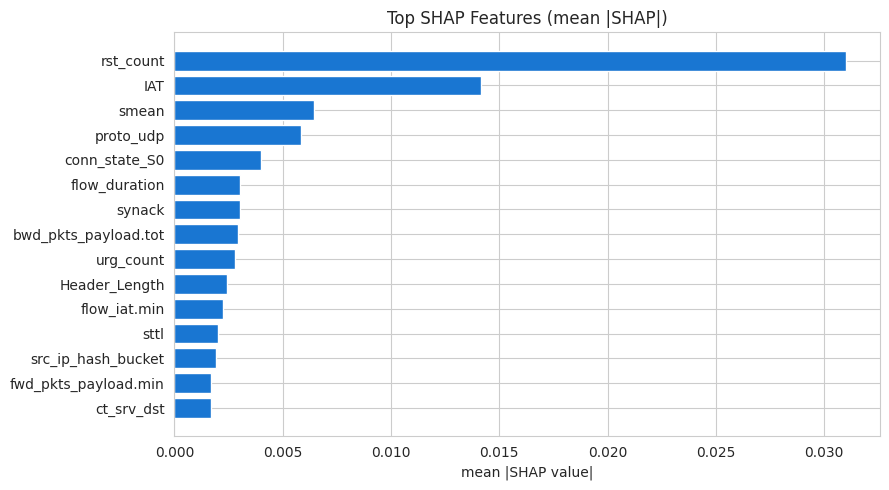

SHAP explanation time: 0.211s
SHAP summary plot:


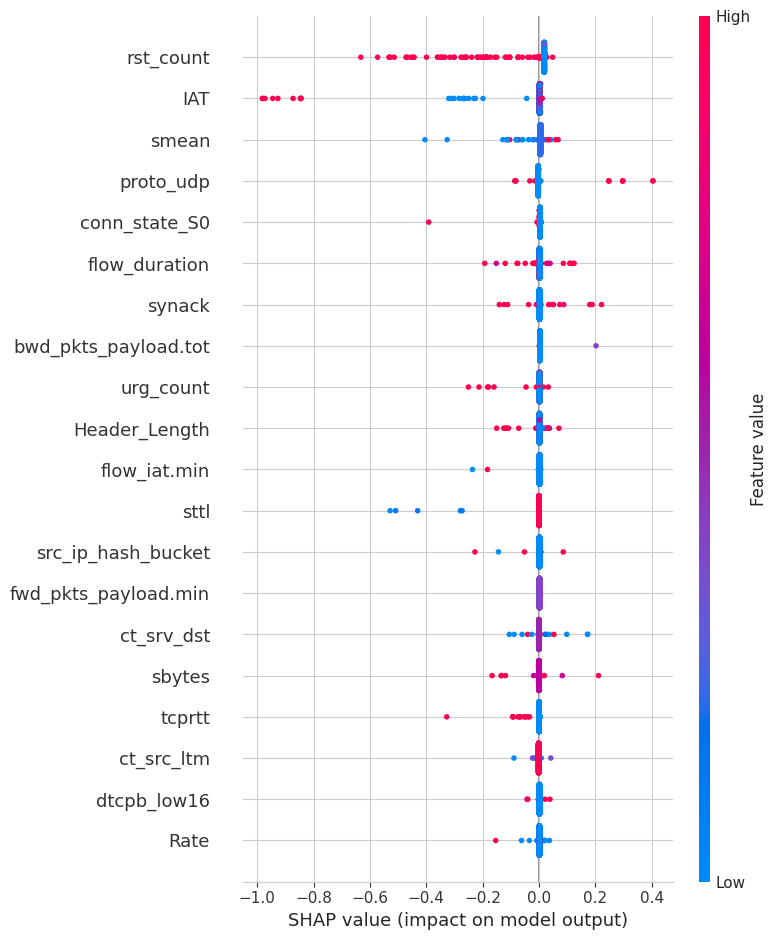

SHAP bar summary plot:


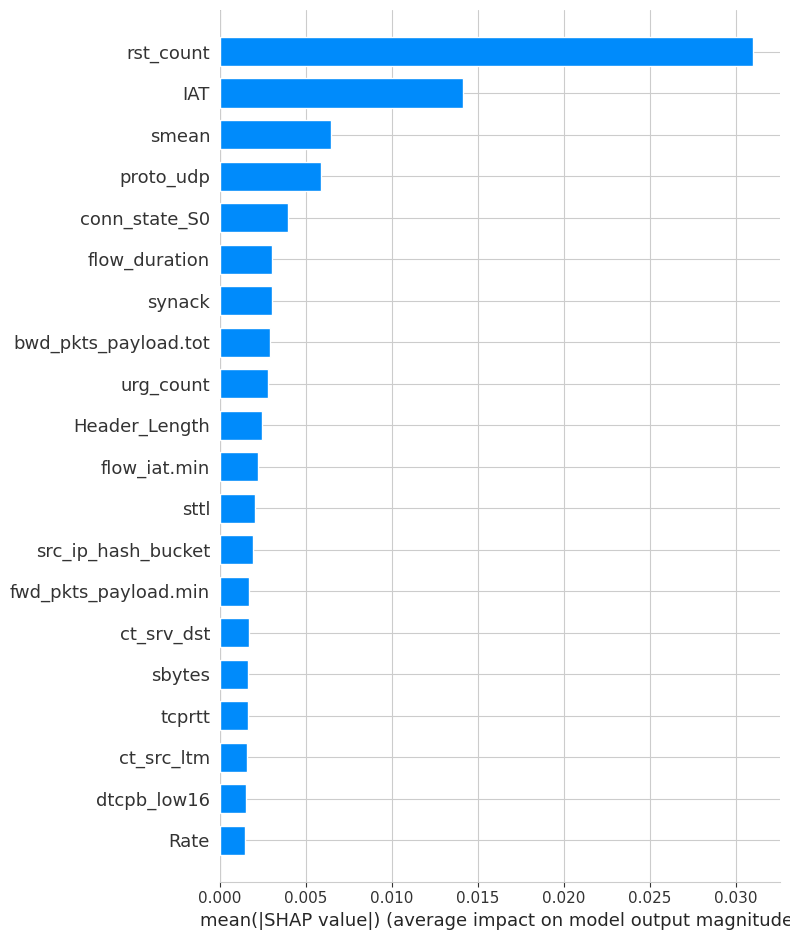

Local SHAP (predicted ATTACK) at sampled index 0


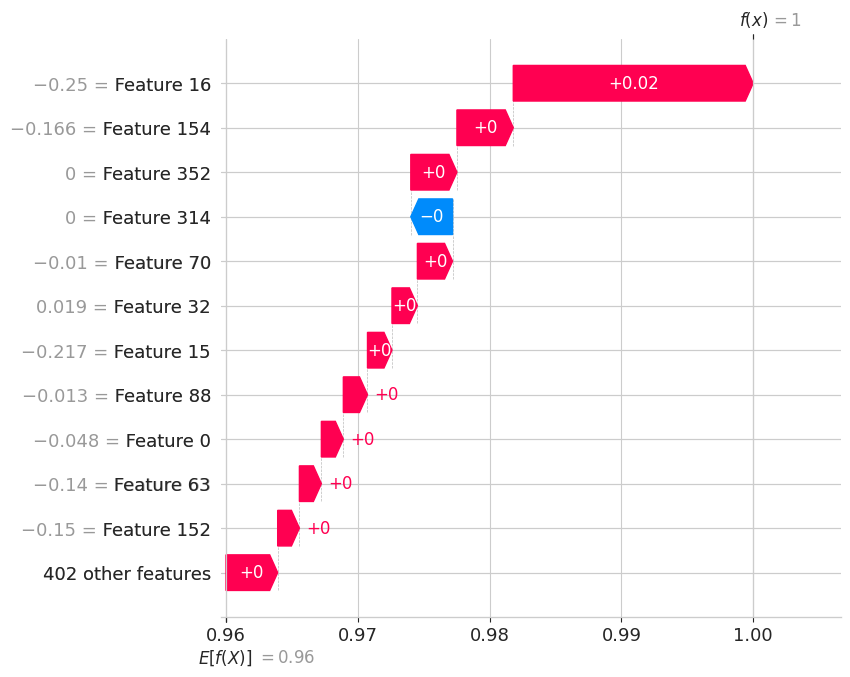

Local SHAP (predicted NORMAL) at sampled index 2


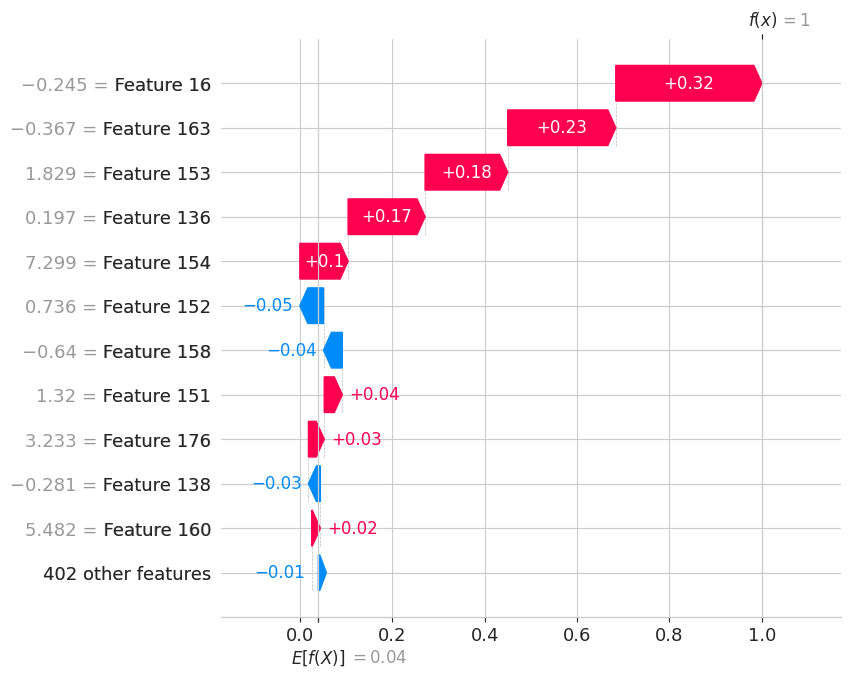

In [12]:
# STEP 2: SHAP global + local analysis and diagrams
# IMPORTANT: SHAP's background masker must match the model's input dimensionality exactly.
# The full_dataset split CSVs can expose 192 columns while persisted artifacts use 188.
# We normalize both matrices and feature-name lists to the model width before explaining.

n_X = int(np.asarray(X_train).shape[1])
n_model = int(getattr(model, "n_features_in_", n_X))

if n_X != n_model:
    raise ValueError(
        f"Feature count mismatch: X_train has {n_X} columns but model.n_features_in_={n_model}. "
        f"Fix training data loading before running SHAP."
    )

feature_names = None

# Candidate name lists (only accept if they match model input width after optional trimming)
_candidates = []

if "INFER_FEATURE_NAMES" in globals() and INFER_FEATURE_NAMES is not None:
    _c = [str(x) for x in list(INFER_FEATURE_NAMES)]
    if len(_c) >= n_model:
        _candidates.append(("INFER_FEATURE_NAMES", _c[:n_model]))

if hasattr(model, "feature_names_in_") and getattr(model, "feature_names_in_", None) is not None:
    _c = [str(x) for x in list(model.feature_names_in_)]
    if len(_c) >= n_model:
        _candidates.append(("model.feature_names_in_", _c[:n_model]))

# Optional: splits metadata (only if it can provide at least model width)
try:
    cwd = Path.cwd()
    if (cwd / "splits").exists():
        _base = cwd
    elif (cwd.parent / "splits").exists():
        _base = cwd.parent
    elif len(cwd.parents) > 1 and (cwd.parents[1] / "splits").exists():
        _base = cwd.parents[1]
    else:
        _base = cwd

    _split_dir = _base / "splits" / "full_dataset"

    _fn_path = _split_dir / "feature_names.csv"
    if _fn_path.exists():
        _loaded = pd.read_csv(_fn_path, header=None).squeeze().tolist()
        _c = [str(x) for x in _loaded]
        if len(_c) >= n_model:
            _candidates.append(("splits/full_dataset/feature_names.csv", _c[:n_model]))

    _pp_path = _split_dir / "preprocessor.pkl"
    _xraw_path = _split_dir / "X_train.csv"
    if _pp_path.exists() and _xraw_path.exists():
        _pp = joblib.load(_pp_path)
        _raw_cols = pd.read_csv(_xraw_path, nrows=1).columns.tolist()
        try:
            _derived = _pp.get_feature_names_out(_raw_cols).tolist()
        except Exception:
            _derived = _pp.get_feature_names_out().tolist()
        _c = [str(x) for x in _derived]
        if len(_c) >= n_model:
            _candidates.append(("preprocessor.get_feature_names_out(...)", _c[:n_model]))
except Exception:
    pass

if _candidates:
    _src, feature_names = _candidates[0]
    if len(_candidates) > 1:
        for _src2, _names2 in _candidates[1:]:
            if _names2 != feature_names:
                print(
                    f"WARNING: multiple {n_model}-length feature name sources disagree "
                    f"({_src} vs {_src2}). Using {_src}."
                )
                break
else:
    feature_names = [f"f{i:03d}" for i in range(n_model)]
    print(
        f"WARNING: could not find any feature name list with length >= model.n_features_in_={n_model}. "
        f"Falling back to generic names {feature_names[0]}..{feature_names[-1]}."
    )

X_train_arr = np.asarray(X_train)
X_test_arr = np.asarray(X_test)

X_train_df = pd.DataFrame(X_train_arr, columns=feature_names)
X_test_df = pd.DataFrame(X_test_arr, columns=feature_names)

bg_size = min(2000, X_train_arr.shape[0])
sample_size = min(1000, X_test_arr.shape[0])

rng = np.random.default_rng(42)
bg_idx = rng.choice(X_train_arr.shape[0], size=bg_size, replace=False)
sample_idx = rng.choice(X_test_arr.shape[0], size=sample_size, replace=False)

bg_X = X_train_arr[bg_idx]
X_sample_X = X_test_arr[sample_idx]

t0 = time.time()
explainer = shap.Explainer(model, bg_X)
try:
    shap_exp = explainer(X_sample_X, check_additivity=False)
except TypeError:
    shap_exp = explainer(X_sample_X)
shap_time = round(time.time() - t0, 3)

sv = np.asarray(shap_exp.values)

# Normalize SHAP outputs for binary classifiers (handles occasional extra output dims)
if sv.ndim == 3:
    if sv.shape[-1] == 2:
        sv = sv[..., 1]
    elif sv.shape[-1] == 1:
        sv = sv[..., 0]
elif sv.ndim > 3:
    raise ValueError(f"Unexpected SHAP values shape: {sv.shape}")

if sv.ndim != 2 or sv.shape[1] != n_model:
    raise ValueError(
        f"SHAP values shape {getattr(sv, 'shape', None)} does not match model.n_features_in_={n_model}."
    )

mean_abs_shap = np.abs(sv).mean(axis=0)
shap_top_idx = np.argsort(mean_abs_shap)[::-1][:15]
shap_top_features = [feature_names[i] for i in shap_top_idx]

shap_table = pd.DataFrame({"feature": shap_top_features, "mean_abs_shap": mean_abs_shap[shap_top_idx]})
print("Top SHAP features:")
print(shap_table.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(shap_table["feature"][::-1], shap_table["mean_abs_shap"][::-1], color="#1976d2")
plt.title("Top SHAP Features (mean |SHAP|)")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

print(f"SHAP explanation time: {shap_time}s")
print("SHAP summary plot:")
shap.summary_plot(sv, X_sample_X, feature_names=feature_names, show=True)

print("SHAP bar summary plot:")
shap.summary_plot(sv, X_sample_X, feature_names=feature_names, plot_type="bar", show=True)

# Local explanation for one attack and one normal sample
X_sample_df = pd.DataFrame(X_sample_X, columns=feature_names)
y_pred_sample = model.predict(X_sample_df)
attack_idx = np.where(y_pred_sample == 1)[0]
normal_idx = np.where(y_pred_sample == 0)[0]

def _select_single_output_explanation(exp, row_idx, preferred_class=1):
    """Return a 1D SHAP Explanation for one sample, handling binary/multi-output layouts."""
    row_exp = exp[row_idx]
    row_vals = np.asarray(row_exp.values)

    # Standard case: already 1D feature contributions.
    if row_vals.ndim == 1:
        return row_exp

    # Multi-output case: pick preferred class if available, else class 0.
    if row_vals.ndim == 2:
        out_idx = preferred_class if row_vals.shape[-1] > preferred_class else 0
        return exp[row_idx, :, out_idx]

    raise ValueError(f"Unsupported local SHAP shape for waterfall: {row_vals.shape}")

if len(attack_idx) > 0:
    i = int(attack_idx[0])
    print(f"Local SHAP (predicted ATTACK) at sampled index {i}")
    shap.plots.waterfall(_select_single_output_explanation(shap_exp, i, preferred_class=1), max_display=12)

if len(normal_idx) > 0:
    j = int(normal_idx[0])
    print(f"Local SHAP (predicted NORMAL) at sampled index {j}")
    shap.plots.waterfall(_select_single_output_explanation(shap_exp, j, preferred_class=0), max_display=12)

# Persist for later cells
XAI_CTX = {
    "feature_names": feature_names,
    "X_train_df": X_train_df,
    "X_test_df": X_test_df,
    "X_sample": X_sample_df,
    "shap_exp": shap_exp,
    "shap_values": sv,
    "shap_top_features": shap_top_features,
    "shap_time_sec": shap_time,
}


Top candidate SHAP-informed rules:
                   rule  coverage  precision_attack  support
           IAT > 0.0051  0.232261          0.953238   293955
          IAT < -0.0039  0.230580          0.953168   291828
flow_duration > -0.0534  0.240039          0.906274   303799
    rst_count > -0.2499  0.238947          0.832916   302417
        smean < -0.1662  0.014539          0.671159    18401
        smean > -0.1662  0.015791          0.619765    19985
     proto_udp > 0.0000  0.017274          0.608059    21863
 conn_state_S0 > 0.0000  0.006156          0.400205     7791
    rst_count < -0.2500  0.000000          0.000000        0
     proto_udp < 0.0000  0.000000          0.000000        0
 conn_state_S0 < 0.0000  0.000000          0.000000        0
flow_duration < -0.0540  0.000000          0.000000        0


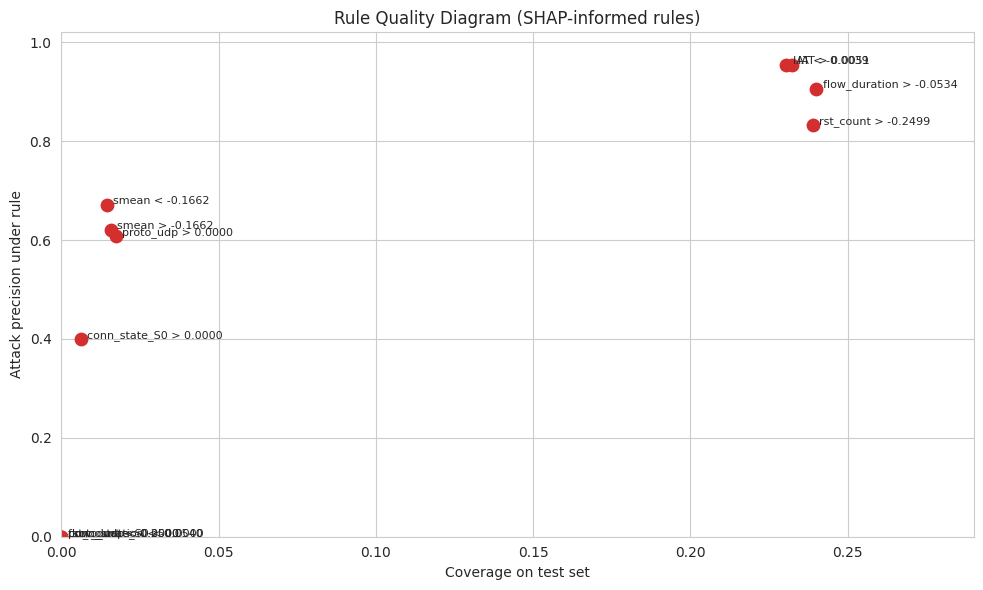


Best rule summary:
  rule: IAT > 0.0051
  coverage: 0.23226074074074074
  precision_attack: 0.9532377404704802
  support: 293955


In [13]:
# STEP 3: SHAP-based manual rule drafting + rule diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_test_df = XAI_CTX['X_test_df']
feature_names = XAI_CTX['feature_names']
shap_values = XAI_CTX['shap_values']
X_sample = XAI_CTX['X_sample']

# Build candidate thresholds from top SHAP features using sampled quantiles.
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:6]

def eval_rule(mask, y_true):
    coverage = float(mask.mean())
    if mask.sum() == 0:
        return {'coverage': 0.0, 'precision_attack': 0.0, 'support': 0}
    precision_attack = float((y_true[mask] == 1).mean())
    return {
        'coverage': coverage,
        'precision_attack': precision_attack,
        'support': int(mask.sum())
    }

rule_rows = []
y_test_arr = np.asarray(y_test)

for i in top_idx:
    f = feature_names[i]
    q75 = float(X_sample[f].quantile(0.75))
    q25 = float(X_sample[f].quantile(0.25))

    mask_hi = X_test_df[f].values > q75
    mask_lo = X_test_df[f].values < q25

    hi_m = eval_rule(mask_hi, y_test_arr)
    lo_m = eval_rule(mask_lo, y_test_arr)

    rule_rows.append({'rule': f'{f} > {q75:.4f}', **hi_m})
    rule_rows.append({'rule': f'{f} < {q25:.4f}', **lo_m})

rule_df = pd.DataFrame(rule_rows).sort_values(['precision_attack', 'coverage'], ascending=False)
print('Top candidate SHAP-informed rules:')
print(rule_df.head(12).to_string(index=False))

# Plot rule quality diagram (precision vs coverage)
plot_df = rule_df.head(12).copy()
plt.figure(figsize=(10, 6))
plt.scatter(plot_df['coverage'], plot_df['precision_attack'], s=80, c='#d32f2f')
for _, r in plot_df.iterrows():
    plt.text(r['coverage'] + 0.002, r['precision_attack'] + 0.002, r['rule'][:28], fontsize=8)
plt.title('Rule Quality Diagram (SHAP-informed rules)')
plt.xlabel('Coverage on test set')
plt.ylabel('Attack precision under rule')
plt.xlim(0, min(1.0, max(0.05, plot_df['coverage'].max() + 0.05)))
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

# Best single rule summary
best_rule = plot_df.iloc[0].to_dict() if len(plot_df) else None
if best_rule:
    print('\nBest rule summary:')
    for k, v in best_rule.items():
        print(f'  {k}: {v}')

XAI_CTX['rule_df'] = rule_df



SHAP analysis metrics:
                      metric     value
               shap_time_sec  0.211000
    sparsity_top10_mass_mean  0.698133
     fidelity_mae_top10_mask  0.026000
       stability_cosine_mean  0.927481
faithfulness_prob_drop_top10 -0.006000


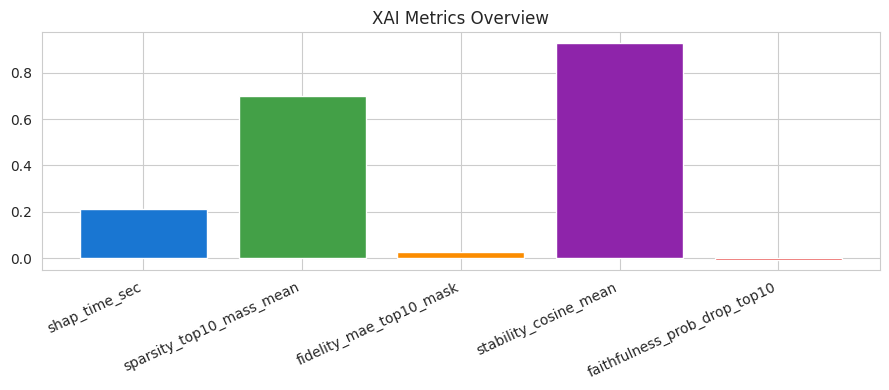

In [14]:
# STEP 4: SHAP analysis metrics (fidelity, stability, sparsity, faithfulness, time)
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_sample = XAI_CTX['X_sample']
shap_values = XAI_CTX['shap_values']
feature_names = XAI_CTX['feature_names']

# Sparsity: concentration of contribution mass in top features
abs_sv = np.abs(shap_values)
frac_top10 = np.sum(np.sort(abs_sv, axis=1)[:, -10:], axis=1) / (np.sum(abs_sv, axis=1) + 1e-12)
sparsity_top10_mean = float(np.mean(frac_top10))

# Fidelity: compare model probability change after masking non-top features
proba_full = model.predict_proba(X_sample)[:, 1]
topk = 10
masked = np.zeros_like(X_sample.values)
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    masked[r, idx] = X_sample.values[r, idx]
proba_masked = model.predict_proba(masked)[:, 1]
fidelity_mae = float(np.mean(np.abs(proba_full - proba_masked)))

# Stability: SHAP similarity for neighboring samples
sub_n = min(300, X_sample.shape[0])
sub_idx = np.random.choice(X_sample.shape[0], size=sub_n, replace=False)
X_sub = X_sample.iloc[sub_idx].reset_index(drop=True)
sv_sub = shap_values[sub_idx]

dists = np.linalg.norm(X_sub.values[:, None, :] - X_sub.values[None, :, :], axis=2)
np.fill_diagonal(dists, np.inf)
nn = np.argmin(dists, axis=1)

cos_sims = []
for i in range(sub_n):
    a = sv_sub[i]
    b = sv_sub[nn[i]]
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    cos_sims.append(float(np.dot(a, b) / denom))
stability_cos_mean = float(np.mean(cos_sims))

# Faithfulness: remove top-k SHAP features and measure probability drop
ablated = X_sample.values.copy()
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    ablated[r, idx] = 0.0
proba_ablated = model.predict_proba(ablated)[:, 1]
faithfulness_drop = float(np.mean(proba_full - proba_ablated))

metrics_df = pd.DataFrame([
    {'metric': 'shap_time_sec', 'value': XAI_CTX.get('shap_time_sec', np.nan)},
    {'metric': 'sparsity_top10_mass_mean', 'value': sparsity_top10_mean},
    {'metric': 'fidelity_mae_top10_mask', 'value': fidelity_mae},
    {'metric': 'stability_cosine_mean', 'value': stability_cos_mean},
    {'metric': 'faithfulness_prob_drop_top10', 'value': faithfulness_drop},
])

print('SHAP analysis metrics:')
print(metrics_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.bar(metrics_df['metric'], metrics_df['value'], color=['#1976d2', '#43a047', '#fb8c00', '#8e24aa', '#e53935'])
plt.xticks(rotation=25, ha='right')
plt.title('XAI Metrics Overview')
plt.tight_layout()
plt.show()

XAI_CTX['metrics_df'] = metrics_df




LIME explanation (attack_like) at sampled index 0:
                       rule    weight
     fwd_bulk_rate <= -0.01  0.455718
          state_CON <= 0.00  0.280208
   conn_state_RSTRH <= 0.00  0.280023
      conn_state_S2 <= 0.00  0.280023
       fwd_iat.tot <= -0.02  0.207593
          state_REQ <= 0.00  0.193852
 fwd_subflow_bytes <= -0.04  0.193605
fwd_header_size_min <= 0.03  0.193426
        ct_ftp_cmd <= -0.06  0.187753
         proto_icmp <= 0.00 -0.035635
          proto_dgp <= 0.00 -0.035791
    bwd_bulk_bytes <= -0.01 -0.047857


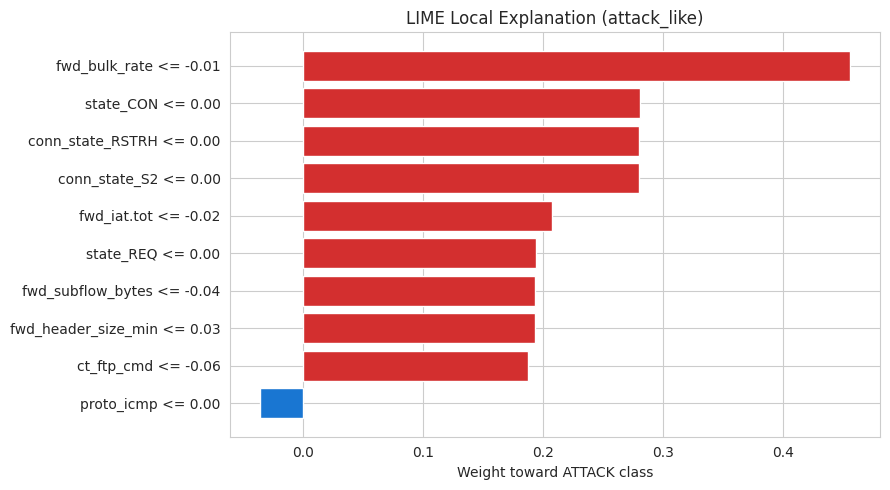


LIME explanation (normal_like) at sampled index 2:
                   rule    weight
      idle.avg <= -0.15  0.292689
 conn_state_SHR <= 0.00  0.275190
   service_smtp <= 0.00  0.272655
   bwd_iat.std <= -0.07  0.216335
  conn_state_S0 <= 0.00  0.211258
     dns_rcode <= -0.03  0.188019
 dns_rejected_T <= 0.00  0.138585
      proto_cbt <= 0.00 -0.036157
  conn_state_S2 <= 0.00 -0.036280
bwd_bulk_bytes <= -0.01 -0.036280
       dns_AA_T <= 0.00 -0.036402
      proto_rvd <= 0.00 -0.176253


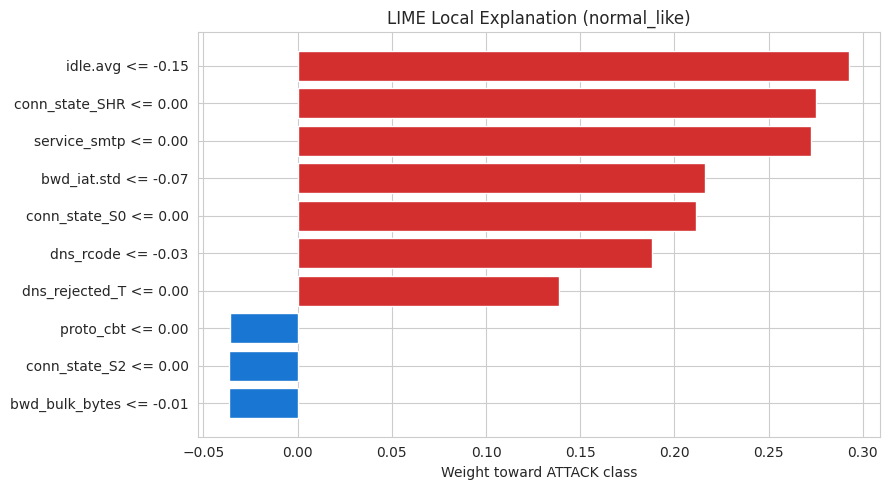


Aggregated LIME rule importance (mean |weight| across explained samples):
                       rule  abs_weight
     fwd_bulk_rate <= -0.01    0.455718
          idle.avg <= -0.15    0.292689
          state_CON <= 0.00    0.280208
   conn_state_RSTRH <= 0.00    0.280023
     conn_state_SHR <= 0.00    0.275190
       service_smtp <= 0.00    0.272655
       bwd_iat.std <= -0.07    0.216335
      conn_state_S0 <= 0.00    0.211258
       fwd_iat.tot <= -0.02    0.207593
          state_REQ <= 0.00    0.193852
 fwd_subflow_bytes <= -0.04    0.193605
fwd_header_size_min <= 0.03    0.193426


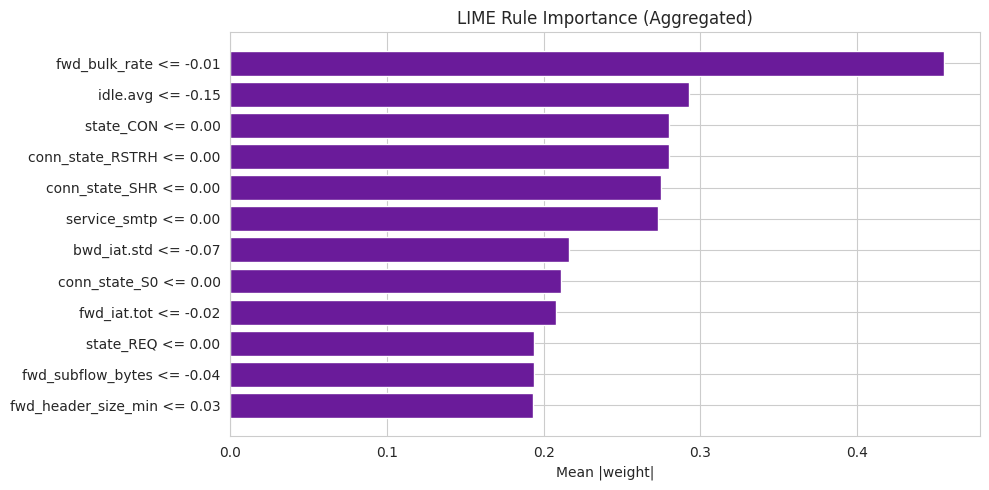

In [15]:
# STEP 5: LIME local explanations + diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_train_df = XAI_CTX['X_train_df']
X_sample = XAI_CTX['X_sample']
feature_names = XAI_CTX['feature_names']

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=['normal', 'attack'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Explain one predicted attack and one predicted normal sample.
preds = model.predict(X_sample)
attack_ix = np.where(preds == 1)[0]
normal_ix = np.where(preds == 0)[0]
chosen = []
if len(attack_ix) > 0:
    chosen.append(('attack_like', int(attack_ix[0])))
if len(normal_ix) > 0:
    chosen.append(('normal_like', int(normal_ix[0])))
if not chosen:
    chosen.append(('fallback', 0))

lime_rows = []
for tag, idx in chosen:
    exp = lime_explainer.explain_instance(
        X_sample.iloc[idx].values,
        model.predict_proba,
        num_features=12
    )
    pairs = exp.as_list(label=1)

    local_df = pd.DataFrame(pairs, columns=['rule', 'weight']).sort_values('weight', ascending=False)
    print(f'\nLIME explanation ({tag}) at sampled index {idx}:')
    print(local_df.to_string(index=False))

    plt.figure(figsize=(9, 5))
    plot_df = local_df.head(10).iloc[::-1]
    colors = ['#d32f2f' if w > 0 else '#1976d2' for w in plot_df['weight']]
    plt.barh(plot_df['rule'], plot_df['weight'], color=colors)
    plt.title(f'LIME Local Explanation ({tag})')
    plt.xlabel('Weight toward ATTACK class')
    plt.tight_layout()
    plt.show()

    for r, w in pairs:
        lime_rows.append({'sample_tag': tag, 'rule': r, 'weight': float(w)})

lime_df = pd.DataFrame(lime_rows)
agg_lime = (lime_df.assign(abs_weight=lambda d: d['weight'].abs())
                  .groupby('rule', as_index=False)['abs_weight']
                  .mean()
                  .sort_values('abs_weight', ascending=False)
                  .head(12))

print('\nAggregated LIME rule importance (mean |weight| across explained samples):')
print(agg_lime.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(agg_lime['rule'][::-1], agg_lime['abs_weight'][::-1], color='#6a1b9a')
plt.title('LIME Rule Importance (Aggregated)')
plt.xlabel('Mean |weight|')
plt.tight_layout()
plt.show()

XAI_CTX['lime_df'] = lime_df



In [16]:
# STEP 6: Final XAI summary table
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

metrics_df = XAI_CTX.get('metrics_df', pd.DataFrame(columns=['metric', 'value']))
rule_df = XAI_CTX.get('rule_df', pd.DataFrame())
lime_df = XAI_CTX.get('lime_df', pd.DataFrame())

best_rule = None
if len(rule_df) > 0:
    best_rule = rule_df.sort_values(['precision_attack', 'coverage'], ascending=False).iloc[0]

summary_rows = [
    {'item': 'model', 'value': MODEL_NAME if 'MODEL_NAME' in globals() else 'DecisionTree'},
    {'item': 'dataset', 'value': 'full_dataset'},
    {'item': 'xai_samples_shap', 'value': len(XAI_CTX.get('X_sample', []))},
    {'item': 'shap_top_feature_1', 'value': (XAI_CTX.get('shap_top_features') or ['NA'])[0]},
    {'item': 'lime_rules_collected', 'value': int(len(lime_df))},
]

if best_rule is not None:
    summary_rows.extend([
        {'item': 'best_rule', 'value': best_rule['rule']},
        {'item': 'best_rule_precision_attack', 'value': round(float(best_rule['precision_attack']), 6)},
        {'item': 'best_rule_coverage', 'value': round(float(best_rule['coverage']), 6)},
    ])

for _, r in metrics_df.iterrows():
    summary_rows.append({'item': r['metric'], 'value': round(float(r['value']), 6)})

xai_summary = pd.DataFrame(summary_rows)
print('Final XAI summary:')
print(xai_summary.to_string(index=False))



xai_summary.to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv", index=False)
print(f'\nSaved: {RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv')

Final XAI summary:
                        item        value
                       model DecisionTree
                     dataset full_dataset
            xai_samples_shap         1000
          shap_top_feature_1    rst_count
        lime_rules_collected           24
                   best_rule IAT > 0.0051
  best_rule_precision_attack     0.953238
          best_rule_coverage     0.232261
               shap_time_sec        0.211
    sparsity_top10_mass_mean     0.698133
     fidelity_mae_top10_mask        0.026
       stability_cosine_mean     0.927481
faithfulness_prob_drop_top10       -0.006

Saved: /content/drive/MyDrive/MLmodeling/XAI/results/full_dataset//FULL_02_DecisionTree_xai_summary.csv
